# Model × Model Statistical Comparison

Win-rate matrices tell you *how often* model A beats model B, but not *whether* the difference is statistically meaningful.  
This notebook uses **paired statistical tests** to answer that question.

Pairing is valid because every model was evaluated on the **identical CV windows** (same expanding schedule, same horizon).

| Test | Assumption | When to prefer |
|------|-----------|----------------|
| Paired t-test | fold differences ~ Normal | large fold counts, symmetric differences |
| Wilcoxon signed-rank | distribution-free | small fold counts, skewed differences |

**Scope:** discrete + expanding artifacts, all models (no CNN), h=1 and h=5  
**Primary metric:** `balanced_accuracy`  
**Significance:** `*` p<0.10 · `**` p<0.05 · `***` p<0.01 · `ns` not significant

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro
from itertools import combinations
from config import ARTIFACTS_PATH

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

## 1  Load & Filter Artifacts

In [3]:
def load_artifacts(path: pathlib.Path) -> dict:
    arts = {}
    for f in sorted(path.glob('*.pkl')):
        a = joblib.load(f)
        if 'cv_summary' not in a or 'cv_metrics' not in a:
            print(f'  skip (old format): {f.name}')
            continue
        arts[f.stem] = a
        print(f'  {f.stem:40s}  h={a["horizon"]}  mode={a["mode"]:<10s}'
              f'  target={a.get("target_type", "discrete"):<10s}  folds={len(a["cv_metrics"])}')
    print(f'\n{len(arts)} artifact(s) loaded.')
    return arts

all_arts = load_artifacts(ARTIFACTS_PATH)

  gru_h1_expanding_discrete                 h=1  mode=expanding   target=discrete    folds=70
  gru_h5_expanding_discrete                 h=5  mode=expanding   target=discrete    folds=66
  lstm_h1_expanding_discrete                h=1  mode=expanding   target=discrete    folds=70
  lstm_h5_expanding_discrete                h=5  mode=expanding   target=discrete    folds=66
  markov_h1_expanding_discrete              h=1  mode=expanding   target=discrete    folds=70
  markov_h5_expanding_discrete              h=5  mode=expanding   target=discrete    folds=66
  rf_h1_expanding_discrete                  h=1  mode=expanding   target=discrete    folds=70
  rf_h5_expanding_discrete                  h=5  mode=expanding   target=discrete    folds=66
  xgb_h1_expanding_discrete                 h=1  mode=expanding   target=discrete    folds=70
  xgb_h5_expanding_discrete                 h=5  mode=expanding   target=discrete    folds=66

10 artifact(s) loaded.


In [4]:
# Discrete + expanding only; exclude CNN variants per spec
CNN_KEYS = {'cnn_gru', 'cnn_lstm', 'cnn_rnn'}

arts = {
    k: v for k, v in all_arts.items()
    if v.get('target_type', 'discrete') == 'discrete'
    and v.get('mode') == 'expanding'
    and v.get('model_key') not in CNN_KEYS
}

print(f'Artifacts in scope: {len(arts)}')
for k in sorted(arts, key=lambda x: (arts[x]['horizon'], arts[x]['model_key'])):
    a = arts[k]
    print(f'  {k:40s}  model={a["model_key"]:10s}  h={a["horizon"]}  folds={len(a["cv_metrics"])}')

horizons = sorted({a['horizon'] for a in arts.values()})
print(f'\nHorizons found: {horizons}')

Artifacts in scope: 10
  gru_h1_expanding_discrete                 model=gru         h=1  folds=70
  lstm_h1_expanding_discrete                model=lstm        h=1  folds=70
  markov_h1_expanding_discrete              model=markov      h=1  folds=70
  rf_h1_expanding_discrete                  model=rf          h=1  folds=70
  xgb_h1_expanding_discrete                 model=xgb         h=1  folds=70
  gru_h5_expanding_discrete                 model=gru         h=5  folds=66
  lstm_h5_expanding_discrete                model=lstm        h=5  folds=66
  markov_h5_expanding_discrete              model=markov      h=5  folds=66
  rf_h5_expanding_discrete                  model=rf          h=5  folds=66
  xgb_h5_expanding_discrete                 model=xgb         h=5  folds=66

Horizons found: [1, 5]


## 2  Helper Functions

In [5]:
def sig_stars(p) -> str:
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return 'n/a'
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return 'ns'


def extract_fold_scores(arts_subset: dict, metric: str) -> dict:
    """artifact_stem -> np.array of per-fold metric values."""
    return {
        stem: np.array([fold.get(metric, np.nan) for fold in a['cv_metrics']], dtype=float)
        for stem, a in arts_subset.items()
    }


def holm_correction(p_values: np.ndarray) -> np.ndarray:
    """Holm-Bonferroni FWER correction (no external dependency)."""
    p = np.asarray(p_values, dtype=float)
    finite = np.isfinite(p)
    p_adj = np.full_like(p, np.nan)
    if finite.sum() == 0:
        return p_adj
    n = finite.sum()
    idx = np.where(finite)[0]
    order = idx[np.argsort(p[idx])]
    vals = np.array([p[i] * (n - rank) for rank, i in enumerate(order)])
    for i in range(1, len(vals)):
        vals[i] = max(vals[i], vals[i - 1])
    vals = np.minimum(vals, 1.0)
    for rank, i in enumerate(order):
        p_adj[i] = vals[rank]
    return p_adj

In [6]:
def paired_tests(sa: np.ndarray, sb: np.ndarray) -> dict:
    """
    Paired t-test + Wilcoxon signed-rank on aligned fold arrays.
    mean_diff = mean(sa) - mean(sb)  (positive => sa better)
    """
    n = min(len(sa), len(sb))
    a, b = sa[:n], sb[:n]
    diffs = a - b
    valid = np.isfinite(diffs)
    d_v = diffs[valid]

    std_d = float(np.nanstd(d_v, ddof=1)) if len(d_v) > 1 else np.nan
    mean_d = float(np.nanmean(diffs))

    out = {
        'n_folds':   int(valid.sum()),
        'mean_a':    float(np.nanmean(a)),
        'mean_b':    float(np.nanmean(b)),
        'mean_diff': mean_d,
        'std_diff':  std_d,
        'cohens_d':  mean_d / std_d if np.isfinite(std_d) and std_d > 0 else np.nan,
    }

    # Paired t-test (two-sided)
    if out['n_folds'] >= 3:
        t, p = ttest_rel(a[valid], b[valid])
        out['t_stat'], out['p_ttest'] = float(t), float(p)
    else:
        out['t_stat'], out['p_ttest'] = np.nan, np.nan

    # Wilcoxon signed-rank (two-sided)
    nonzero = d_v[d_v != 0]
    if len(nonzero) >= 5:
        w, p = wilcoxon(d_v)
        out['w_stat'], out['p_wilcoxon'] = float(w), float(p)
    else:
        out['w_stat'], out['p_wilcoxon'] = np.nan, np.nan

    return out


def compute_pairwise(scores: dict) -> tuple:
    """
    Compute all pairwise statistics for a set of models.

    Returns
    -------
    delta      : DataFrame  mean_i - mean_j  (positive = row model better)
    pval_t     : DataFrame  two-sided paired t-test p-values
    pval_w     : DataFrame  two-sided Wilcoxon p-values
    cohd       : DataFrame  Cohen's d  (positive = row model better)
    mean_scores: dict        model -> mean balanced accuracy
    all_pairs  : list[dict]  raw stats for every pair
    """
    names = sorted(scores)
    empty = lambda: pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
    delta, pval_t, pval_w, cohd = empty(), empty(), empty(), empty()
    mean_scores = {n: float(np.nanmean(scores[n])) for n in names}
    all_pairs = []

    for a, b in combinations(names, 2):
        res = paired_tests(scores[a], scores[b])
        d, cd = res['mean_diff'], res['cohens_d']

        delta.loc[a, b] =  d;   delta.loc[b, a] = -d
        pval_t.loc[a, b] = res['p_ttest'];    pval_t.loc[b, a] = res['p_ttest']
        pval_w.loc[a, b] = res['p_wilcoxon']; pval_w.loc[b, a] = res['p_wilcoxon']
        cohd.loc[a, b]   =  cd if np.isfinite(cd) else np.nan
        cohd.loc[b, a]   = -cd if np.isfinite(cd) else np.nan

        res.update({'model_A': a, 'model_B': b})
        all_pairs.append(res)

    for n in names:
        delta.loc[n, n] = 0.0
        pval_t.loc[n, n] = 1.0
        pval_w.loc[n, n] = 1.0
        cohd.loc[n, n]   = 0.0

    return delta, pval_t, pval_w, cohd, mean_scores, all_pairs

In [7]:
def plot_comparison_matrix(
    delta, pval, mean_scores, title,
    metric_label='Balanced Accuracy', vabs=0.04, ax=None
):
    """
    Model × model heatmap.
    Color  = Δ metric (row − col); diverging RdYlGn centered at 0.
    Text   = Δ in percentage-points + significance stars.
    Diagonal = model mean (neutral background).
    """
    names = delta.index.tolist()
    n = len(names)

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(7, n * 1.5), max(6, n * 1.2)))

    # Build annotation matrix
    annot = np.empty((n, n), dtype=object)
    for i, ri in enumerate(names):
        for j, ci in enumerate(names):
            if i == j:
                annot[i, j] = f'μ={mean_scores[ri]:.4f}'
            else:
                d = delta.loc[ri, ci]
                p = pval.loc[ri, ci]
                sign = '+' if d >= 0 else ''
                annot[i, j] = f'{sign}{d * 100:.2f}pp\n{sig_stars(p)}'

    # Color matrix (diagonal = 0 → neutral yellow in RdYlGn)
    color_mat = delta.values.copy().astype(float)
    np.fill_diagonal(color_mat, 0.0)

    sns.heatmap(
        color_mat,
        annot=annot, fmt='',
        xticklabels=names, yticklabels=names,
        cmap='RdYlGn', center=0.0, vmin=-vabs, vmax=vabs,
        linewidths=0.5, linecolor='white',
        annot_kws={'fontsize': 8, 'fontfamily': 'monospace'},
        cbar_kws={'label': f'Δ {metric_label} (row − col)', 'shrink': 0.8},
        ax=ax,
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel('Column model  (baseline)', fontsize=9)
    ax.set_ylabel('Row model', fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

    legend_items = [
        mpatches.Patch(color='none', label='*** p < 0.01'),
        mpatches.Patch(color='none', label='**  p < 0.05'),
        mpatches.Patch(color='none', label='*   p < 0.10'),
        mpatches.Patch(color='none', label='ns  not significant'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=7,
              framealpha=0.85, bbox_to_anchor=(1.0, -0.12), ncol=2)

## 3  Model × Model Matrices

One pair of matrices per horizon (t-test left, Wilcoxon right).  
Cell `[i, j]` shows how much better (green) or worse (red) the **row** model is vs the **column** model, and whether the difference is statistically significant.  
The diagonal shows each model's own mean balanced accuracy.


── h=1 (5 models) ──────────────────────────────────
  gru           folds=70  mean=0.5274  std=0.0306
  lstm          folds=70  mean=0.5234  std=0.0264
  markov        folds=70  mean=0.4992  std=0.0092
  rf            folds=70  mean=0.5316  std=0.0328
  xgb           folds=70  mean=0.5255  std=0.0328


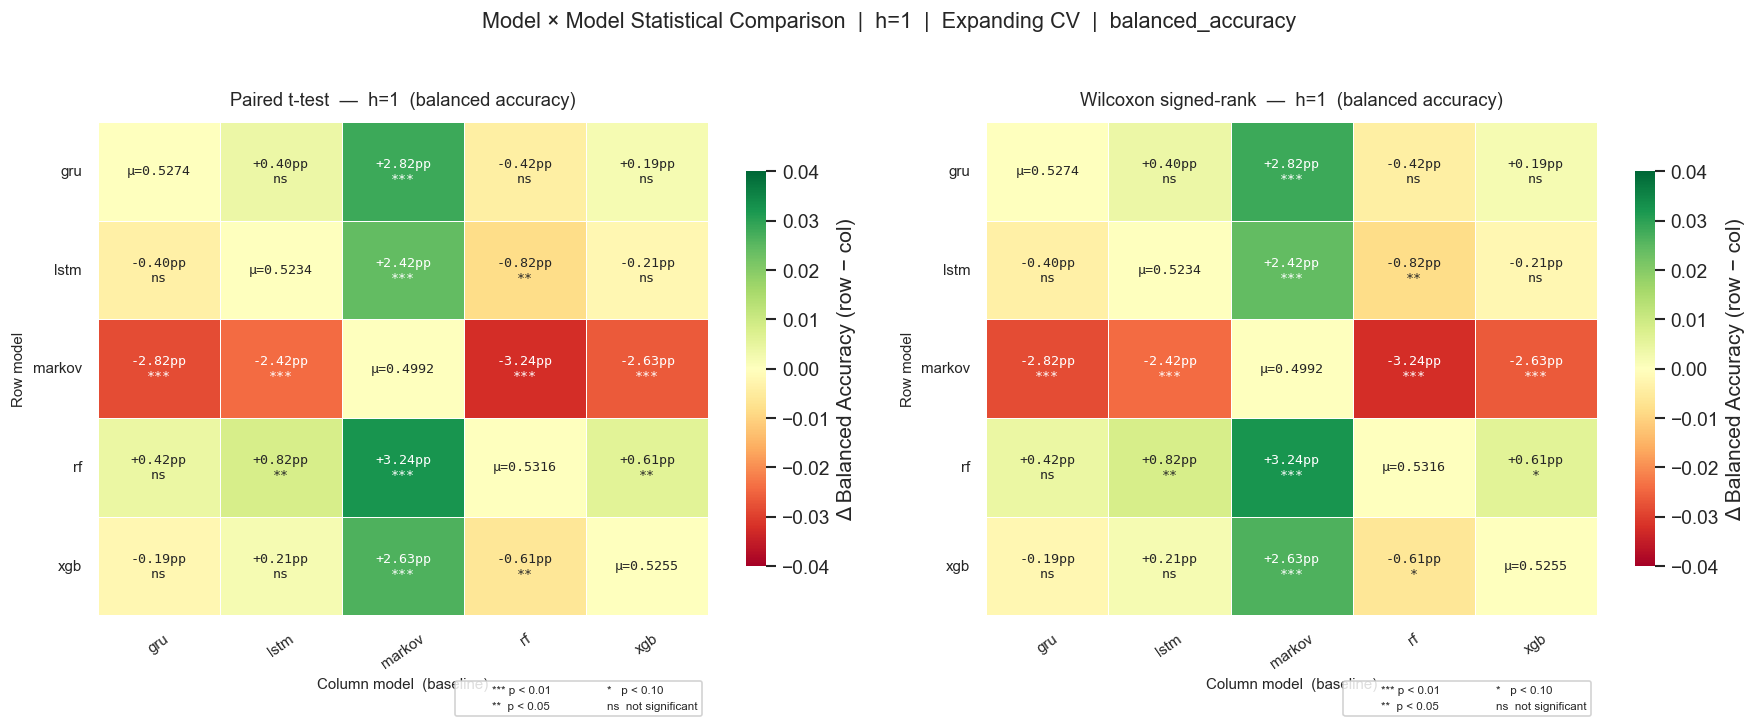


── h=5 (5 models) ──────────────────────────────────
  gru           folds=66  mean=0.5158  std=0.0359
  lstm          folds=66  mean=0.5168  std=0.0364
  markov        folds=66  mean=0.5010  std=0.0118
  rf            folds=66  mean=0.5176  std=0.0464
  xgb           folds=66  mean=0.5070  std=0.0346


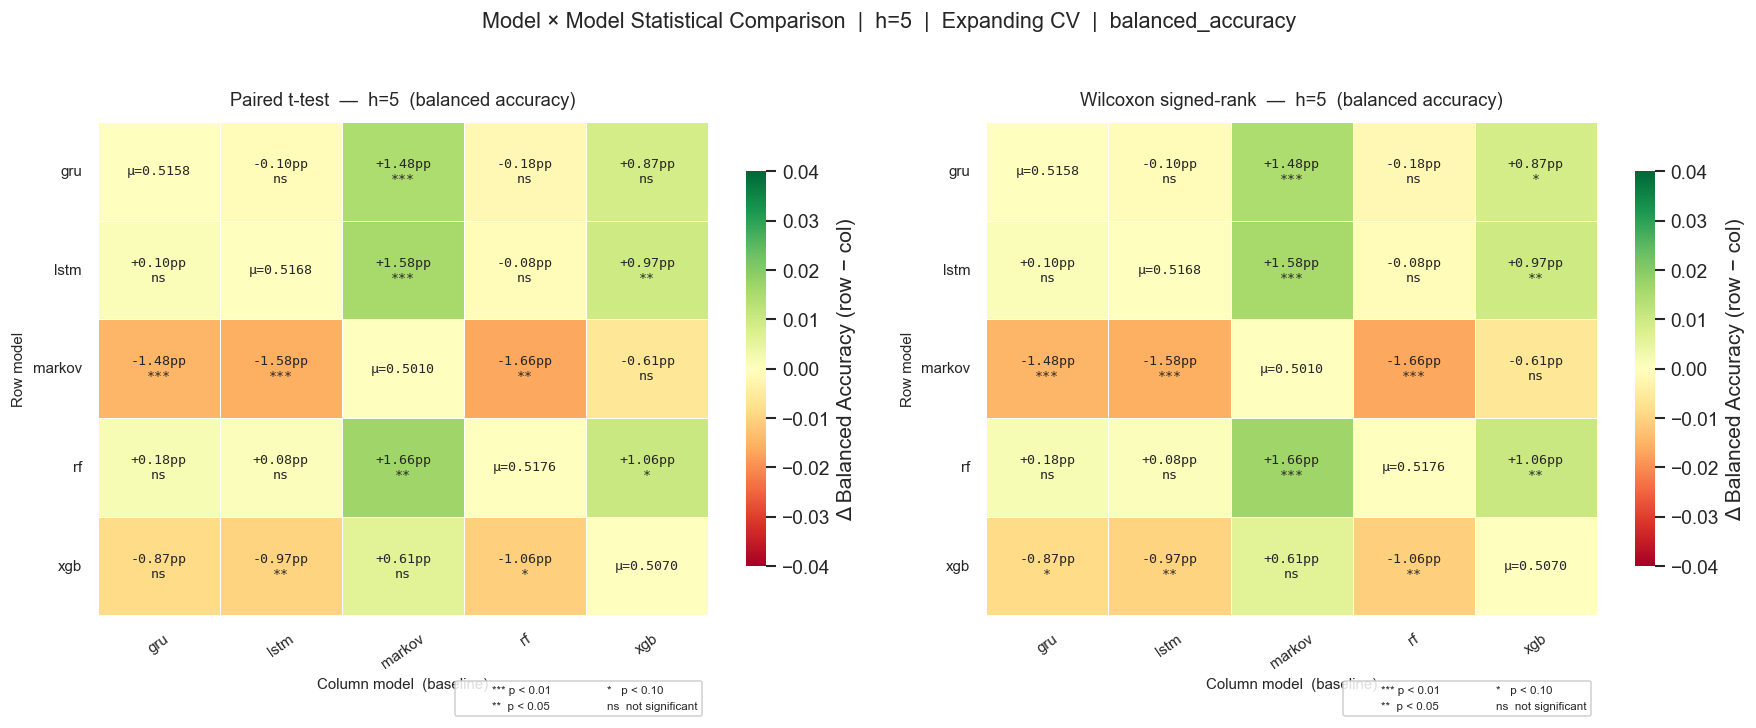

In [8]:
PRIMARY = 'balanced_accuracy'
all_pair_records = []   # accumulated for Section 4

for h in horizons:
    arts_h = {k: v for k, v in arts.items() if v['horizon'] == h}
    if len(arts_h) < 2:
        print(f'h={h}: only {len(arts_h)} artifact(s), need ≥ 2 — skipping.')
        continue

    # Use model_key as label (unique within horizon for discrete-expanding)
    scores_raw = extract_fold_scores(arts_h, PRIMARY)
    label_map  = {stem: arts_h[stem]['model_key'] for stem in arts_h}
    scores     = {label_map[k]: v for k, v in scores_raw.items()}

    print(f'\n── h={h} ({len(scores)} models) ──────────────────────────────────')
    for name in sorted(scores):
        vals = scores[name]
        n_ok = np.isfinite(vals).sum()
        print(f'  {name:12s}  folds={n_ok:2d}  '
              f'mean={np.nanmean(vals):.4f}  std={np.nanstd(vals):.4f}')

    delta, pval_t, pval_w, cohd, mean_sc, pairs = compute_pairwise(scores)

    # Tag pairs with horizon for later
    for p in pairs:
        p['horizon'] = h
    all_pair_records.extend(pairs)

    # ── Plot ────────────────────────────────────────────────────────
    n = len(scores)
    fig, axes = plt.subplots(1, 2, figsize=(max(14, n * 3.0), max(6, n * 1.2)))

    plot_comparison_matrix(
        delta, pval_t, mean_sc,
        title=f'Paired t-test  —  h={h}  (balanced accuracy)',
        ax=axes[0],
    )
    plot_comparison_matrix(
        delta, pval_w, mean_sc,
        title=f'Wilcoxon signed-rank  —  h={h}  (balanced accuracy)',
        ax=axes[1],
    )

    plt.suptitle(
        f'Model × Model Statistical Comparison  |  h={h}  |  Expanding CV  |  {PRIMARY}',
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## 4  Full Pairwise Test Table

All pair statistics in long format — useful for spot-checking and exporting.

In [9]:
def _fmt(v, decimals=4):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan
    return round(float(v), decimals)

table_rows = []
for r in all_pair_records:
    table_rows.append({
        'h':             r['horizon'],
        'model_A':       r['model_A'],
        'model_B':       r['model_B'],
        'n_folds':       r['n_folds'],
        'mean_A':        _fmt(r['mean_a'],    5),
        'mean_B':        _fmt(r['mean_b'],    5),
        'delta_pp':      _fmt(r['mean_diff'] * 100, 3),
        "cohen's_d":     _fmt(r['cohens_d'],  3),
        't_stat':        _fmt(r['t_stat'],    3),
        'p_ttest':       _fmt(r['p_ttest'],   4),
        'sig_ttest':     sig_stars(r.get('p_ttest')),
        'w_stat':        _fmt(r['w_stat'],    1),
        'p_wilcoxon':    _fmt(r['p_wilcoxon'], 4),
        'sig_wilcoxon':  sig_stars(r.get('p_wilcoxon')),
    })

test_table = pd.DataFrame(table_rows)

if test_table.empty:
    print('No pairs computed yet — need ≥ 2 artifacts per horizon.')
else:
    def _sig_bg(val):
        return {
            '***': 'background-color:#c8f7c5',
            '**':  'background-color:#e8f7c5',
            '*':   'background-color:#fef9c3',
            'ns':  '',
            'n/a': 'background-color:#f0f0f0',
        }.get(val, '')

    (
        test_table
        .sort_values(['h', 'p_ttest'])
        .style
        .applymap(_sig_bg, subset=['sig_ttest', 'sig_wilcoxon'])
        .format(
            {'mean_A': '{:.5f}', 'mean_B': '{:.5f}', 'delta_pp': '{:+.3f}',
             'p_ttest': '{:.4f}', 'p_wilcoxon': '{:.4f}', "cohen's_d": '{:.3f}'},
            na_rep='—',
        )
        .set_caption(f'All pairwise tests  —  {PRIMARY}  —  discrete expanding')
        .set_table_styles([{'selector': 'caption',
                            'props': 'font-size:13px; font-weight:bold;'}])
    )

C:\Users\alexd\AppData\Local\Temp\ipykernel_12108\3363598265.py:43: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_sig_bg, subset=['sig_ttest', 'sig_wilcoxon'])


## 5  Multiple Comparisons Correction  (Holm-Bonferroni)

With K models we run K(K−1)/2 pairwise tests. Without correction the family-wise error rate is inflated.  
Holm-Bonferroni is less conservative than plain Bonferroni while still controlling FWER.

In [10]:
if test_table.empty:
    print('No data to correct.')
else:
    corrected_frames = []
    for h, grp in test_table.groupby('h'):
        grp = grp.copy()
        p_raw = grp['p_ttest'].values.astype(float)
        p_adj = holm_correction(p_raw)
        grp['p_ttest_holm']  = p_adj
        grp['sig_holm']      = [sig_stars(v) for v in p_adj]
        grp['reject_H0']     = np.array([v < 0.05 if np.isfinite(v) else False
                                          for v in p_adj])
        corrected_frames.append(grp)

    corrected_table = pd.concat(corrected_frames)

    def _reject_bg(val):
        return 'background-color:#c8f7c5' if val else ''

    cols = ['h', 'model_A', 'model_B', 'delta_pp', 'p_ttest', 'sig_ttest',
            'p_ttest_holm', 'sig_holm', 'reject_H0']
    (
        corrected_table[cols]
        .sort_values(['h', 'p_ttest_holm'])
        .style
        .applymap(_sig_bg, subset=['sig_ttest', 'sig_holm'])
        .applymap(_reject_bg, subset=['reject_H0'])
        .format({'delta_pp': '{:+.3f}', 'p_ttest': '{:.4f}',
                  'p_ttest_holm': '{:.4f}'}, na_rep='—')
        .set_caption('Holm-Bonferroni corrected p-values  (t-test)')
        .set_table_styles([{'selector': 'caption',
                            'props': 'font-size:13px; font-weight:bold;'}])
    )

C:\Users\alexd\AppData\Local\Temp\ipykernel_12108\58802346.py:26: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_sig_bg, subset=['sig_ttest', 'sig_holm'])
C:\Users\alexd\AppData\Local\Temp\ipykernel_12108\58802346.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_reject_bg, subset=['reject_H0'])


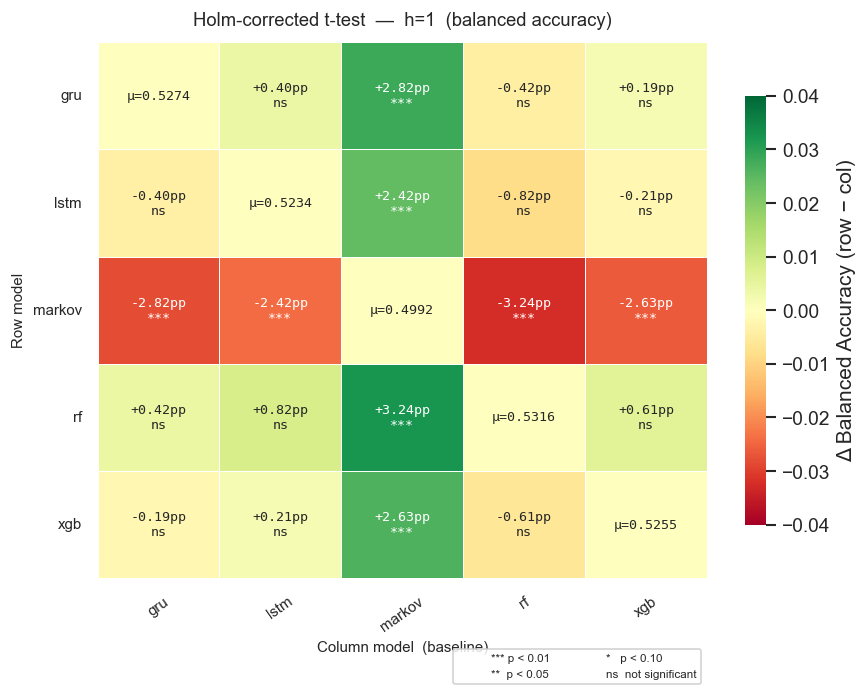

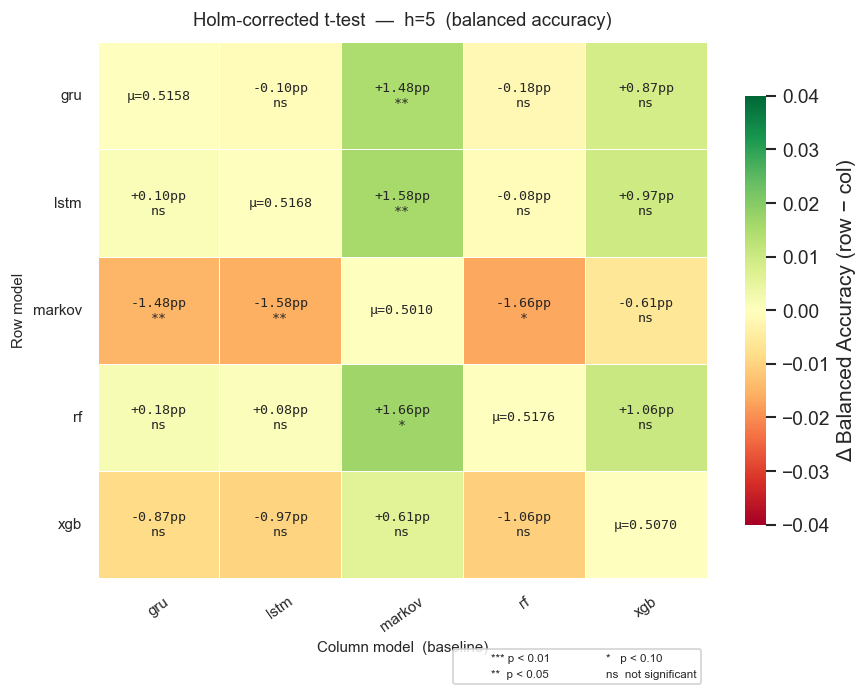

In [11]:
# Visualise Holm-corrected significance as a matrix per horizon
if not test_table.empty:
    for h in horizons:
        arts_h = {k: v for k, v in arts.items() if v['horizon'] == h}
        if len(arts_h) < 2:
            continue

        scores_raw = extract_fold_scores(arts_h, PRIMARY)
        label_map  = {stem: arts_h[stem]['model_key'] for stem in arts_h}
        scores     = {label_map[k]: v for k, v in scores_raw.items()}
        names      = sorted(scores)
        n          = len(names)

        # Rebuild p-value matrix and apply Holm correction
        pairs_all = [
            {'model_A': a, 'model_B': b, **paired_tests(scores[a], scores[b])}
            for a, b in combinations(names, 2)
        ]
        p_raw   = np.array([r['p_ttest'] for r in pairs_all], dtype=float)
        p_holm  = holm_correction(p_raw)

        pval_holm = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
        delta_mat = pd.DataFrame(0.0,   index=names, columns=names, dtype=float)
        for (a, b), p_adj, rec in zip(combinations(names, 2), p_holm, pairs_all):
            pval_holm.loc[a, b] = p_adj
            pval_holm.loc[b, a] = p_adj
            delta_mat.loc[a, b] =  rec['mean_diff']
            delta_mat.loc[b, a] = -rec['mean_diff']
        for nm in names:
            pval_holm.loc[nm, nm] = 1.0

        mean_sc = {nm: float(np.nanmean(scores[nm])) for nm in names}

        fig, ax = plt.subplots(figsize=(max(7, n * 1.5), max(6, n * 1.2)))
        plot_comparison_matrix(
            delta_mat, pval_holm, mean_sc,
            title=f'Holm-corrected t-test  —  h={h}  (balanced accuracy)',
            ax=ax,
        )
        plt.tight_layout()
        plt.show()

## 6  Effect Sizes  (Cohen's d)

Statistical significance depends on sample size. Cohen's d is scale-free:  
small ≥ 0.2 · medium ≥ 0.5 · large ≥ 0.8

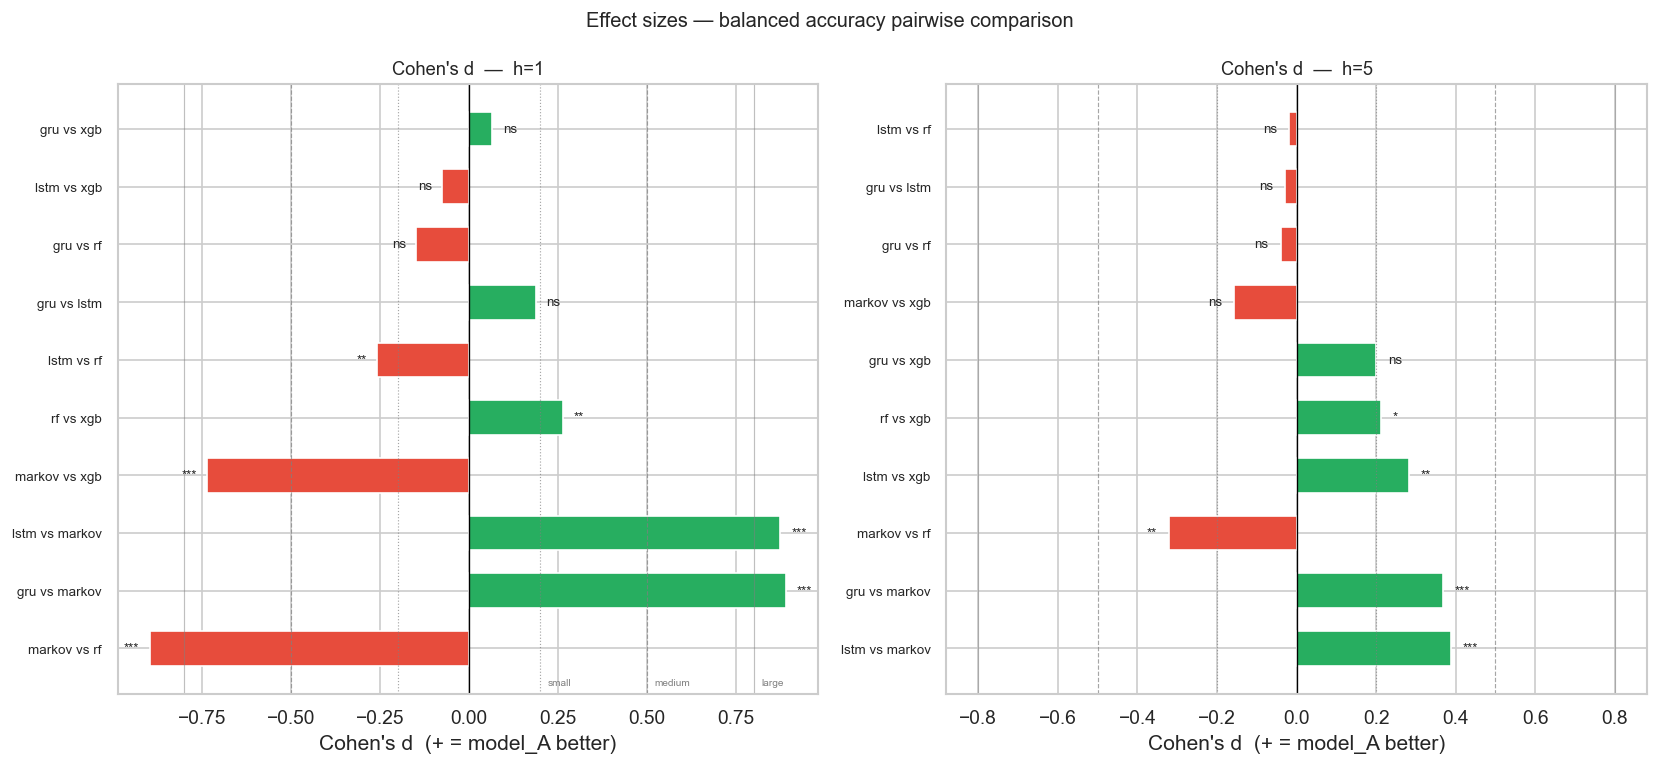

In [12]:
if test_table.empty:
    print('No data for effect sizes.')
else:
    n_h = len(horizons)
    fig, axes = plt.subplots(1, n_h, figsize=(7 * n_h, max(5, len(all_pair_records) // n_h * 0.45 + 2)))
    if n_h == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):
        df_h = test_table[test_table['h'] == h].dropna(subset=["cohen's_d"]).copy()
        if df_h.empty:
            ax.set_visible(False)
            continue

        df_h = df_h.sort_values("cohen's_d", key=abs, ascending=False)
        colors = ['#27ae60' if d > 0 else '#e74c3c' for d in df_h["cohen's_d"]]
        labels = [f'{r.model_A} vs {r.model_B}' for _, r in df_h.iterrows()]

        bars = ax.barh(labels, df_h["cohen's_d"], color=colors, edgecolor='white', height=0.6)
        ax.axvline(0,    color='black', lw=0.8)
        ax.axvline( 0.2, color='grey', lw=0.7, ls=':', alpha=0.7)
        ax.axvline(-0.2, color='grey', lw=0.7, ls=':', alpha=0.7)
        ax.axvline( 0.5, color='grey', lw=0.7, ls='--', alpha=0.7)
        ax.axvline(-0.5, color='grey', lw=0.7, ls='--', alpha=0.7)
        ax.axvline( 0.8, color='grey', lw=0.7, ls='-', alpha=0.5)
        ax.axvline(-0.8, color='grey', lw=0.7, ls='-', alpha=0.5)

        for bar, (_, row) in zip(bars, df_h.iterrows()):
            d = row["cohen's_d"]
            s = sig_stars(row['p_ttest'])
            ax.text(
                d + (0.03 if d >= 0 else -0.03),
                bar.get_y() + bar.get_height() / 2,
                s, va='center', ha='left' if d >= 0 else 'right', fontsize=8,
            )

        # Annotate threshold labels on first axis only
        if ax is axes[0]:
            ymin = ax.get_ylim()[0]
            for xv, lbl in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
                ax.text(xv + 0.02, ymin + 0.1, lbl, fontsize=6, color='grey', va='bottom')

        ax.set_title(f"Cohen's d  —  h={h}", fontsize=11)
        ax.set_xlabel("Cohen's d  (+ = model_A better)")
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle("Effect sizes — balanced accuracy pairwise comparison", fontsize=12)
    plt.tight_layout()
    plt.show()

## 7  Secondary Metrics: ROC-AUC and MCC

Same paired t-test comparison, repeated for `roc_auc` and `mcc`.


══ ROC_AUC ══════════════════════════════════════════


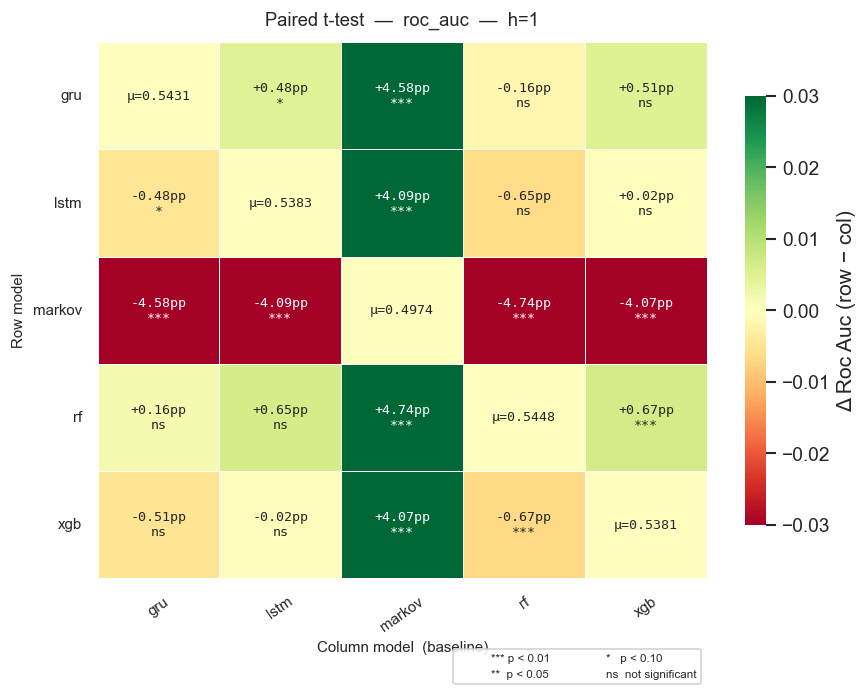

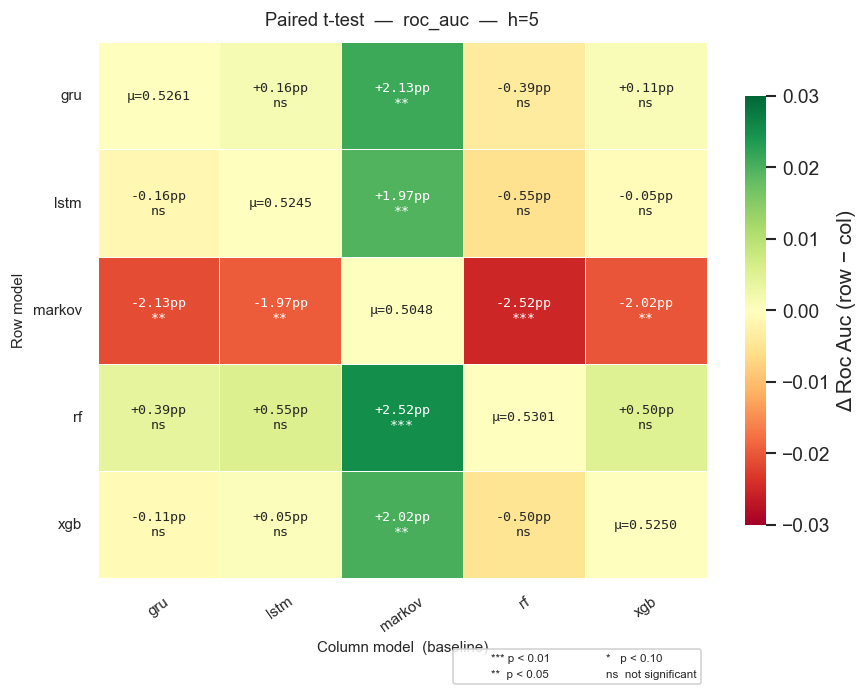


══ MCC ══════════════════════════════════════════


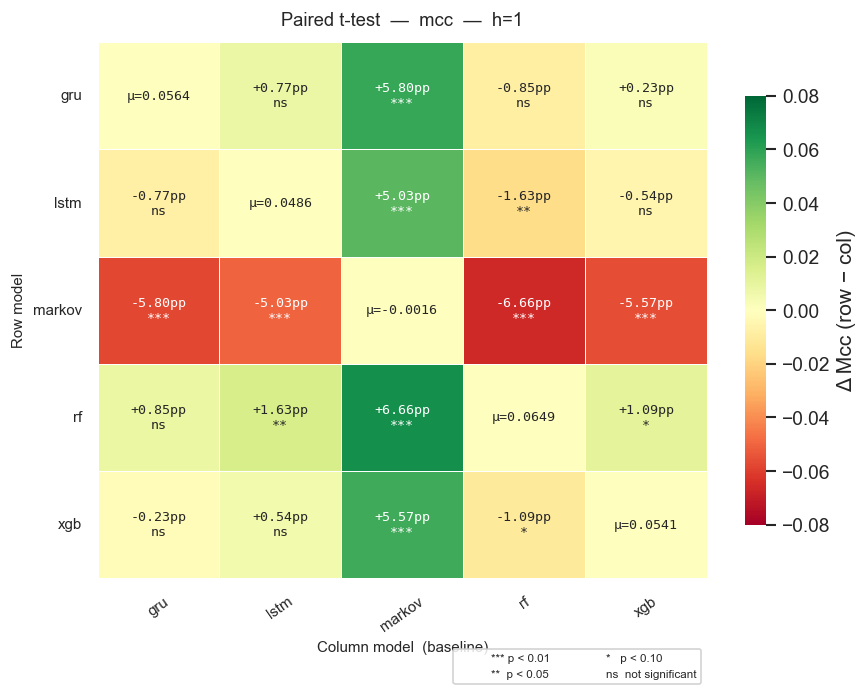

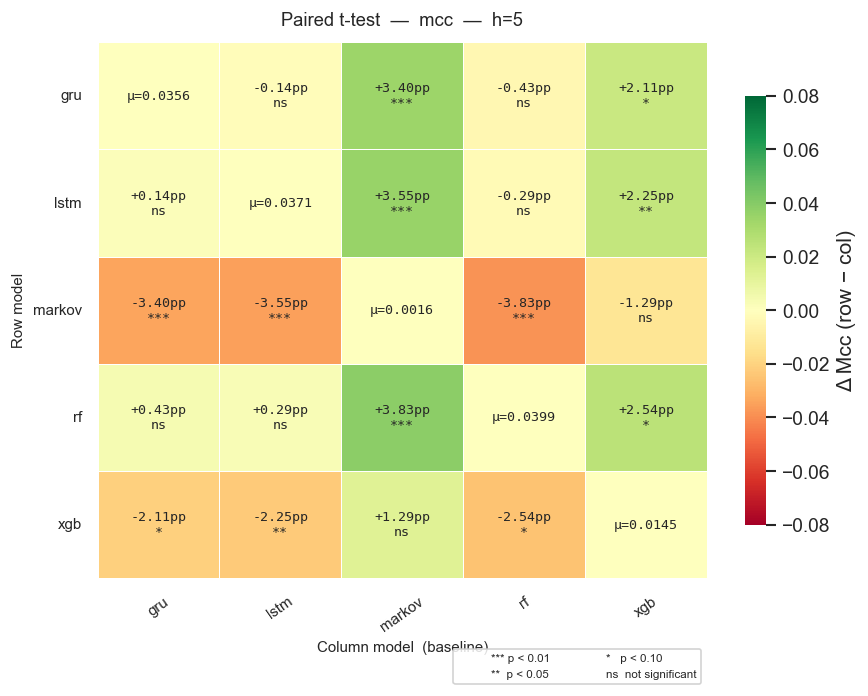

In [13]:
SECONDARY_METRICS = [
    ('roc_auc', 0.03),
    ('mcc',     0.08),
]

for metric, vabs in SECONDARY_METRICS:
    print(f'\n══ {metric.upper()} ══════════════════════════════════════════')
    for h in horizons:
        arts_h = {k: v for k, v in arts.items() if v['horizon'] == h}
        if len(arts_h) < 2:
            continue

        scores_raw = extract_fold_scores(arts_h, metric)
        label_map  = {stem: arts_h[stem]['model_key'] for stem in arts_h}
        scores     = {label_map[k]: v for k, v in scores_raw.items()}

        # Check if metric is present
        if all(np.all(np.isnan(v)) for v in scores.values()):
            print(f'  h={h}: metric "{metric}" not found in cv_metrics — skipping.')
            continue

        delta, pval_t, _, _, mean_sc, _ = compute_pairwise(scores)

        n = len(scores)
        fig, ax = plt.subplots(figsize=(max(7, n * 1.5), max(6, n * 1.2)))
        plot_comparison_matrix(
            delta, pval_t, mean_sc,
            title=f'Paired t-test  —  {metric}  —  h={h}',
            metric_label=metric.replace('_', ' ').title(),
            vabs=vabs, ax=ax,
        )
        plt.tight_layout()
        plt.show()

## 8  Normality Diagnostics  (Shapiro-Wilk)

The paired t-test requires per-fold *differences* to be approximately normal.  
Shapiro-Wilk p > 0.05 → normality not rejected → t-test is trustworthy.  
Shapiro-Wilk p ≤ 0.05 → prefer the Wilcoxon p-value.

In [14]:
norm_rows = []
for h in horizons:
    arts_h = {k: v for k, v in arts.items() if v['horizon'] == h}
    if len(arts_h) < 2:
        continue
    scores_raw = extract_fold_scores(arts_h, PRIMARY)
    label_map  = {stem: arts_h[stem]['model_key'] for stem in arts_h}
    scores     = {label_map[k]: v for k, v in scores_raw.items()}

    for a, b in combinations(sorted(scores), 2):
        n_min = min(len(scores[a]), len(scores[b]))
        diffs = scores[a][:n_min] - scores[b][:n_min]
        valid = diffs[np.isfinite(diffs)]
        if len(valid) < 3:
            continue
        sw_stat, sw_p = shapiro(valid)
        norm_rows.append({
            'h':           h,
            'model_A':     a,
            'model_B':     b,
            'n_diffs':     len(valid),
            'sw_stat':     round(float(sw_stat), 4),
            'p_shapiro':   round(float(sw_p),    4),
            'normal':      bool(sw_p > 0.05),
            'recommended': 't-test' if sw_p > 0.05 else 'Wilcoxon',
        })

if norm_rows:
    norm_df = pd.DataFrame(norm_rows)

    def _norm_bg(val):
        return 'background-color:#c8f7c5' if val else 'background-color:#ffd5d5'

    (
        norm_df
        .sort_values(['h', 'p_shapiro'])
        .style
        .applymap(_norm_bg, subset=['normal'])
        .format({'p_shapiro': '{:.4f}', 'sw_stat': '{:.4f}'})
        .set_caption('Shapiro-Wilk test on per-fold differences  (p>0.05 = normal)')
        .set_table_styles([{'selector': 'caption',
                            'props': 'font-size:13px; font-weight:bold;'}])
    )
else:
    print('Not enough pairs for normality testing.')

C:\Users\alexd\AppData\Local\Temp\ipykernel_12108\1440603359.py:38: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(_norm_bg, subset=['normal'])


## Notes on Interpretation

**Two-sided tests** are used throughout. The *direction* of any significant difference is given by the sign of `delta_pp`.

**Power caveat**: with ~15–20 CV folds, statistical power is limited. A non-significant result (`ns`) does **not** mean the models are equivalent — it may simply mean the fold count is too small to detect a real but small difference.

**Both tests agree** → stronger evidence.  
**Tests disagree** → check the Shapiro-Wilk result (Section 8) to choose which to trust.

**After Holm correction** (Section 5): only pairs surviving Holm at α=0.05 represent strong evidence of a true performance difference.

**Effect size > significance**: a pair can be statistically significant but have a tiny Cohen's d (|d| < 0.2), meaning the practical difference is negligible. Always check both.